In [1]:
import os
import time
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

os.makedirs("data", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [2]:
pantry = pd.read_csv("data/pantry.csv")
consumption = pd.read_csv("data/consumption_log.csv")
recipes = pd.read_csv("data/recipes.csv")
user = pd.read_csv("data/user_profile.csv")

print("Loaded:")
print("pantry:", pantry.shape)
print("consumption:", consumption.shape)
print("recipes:", recipes.shape)
print("user:", user.shape)

Loaded:
pantry: (15, 6)
consumption: (90, 4)
recipes: (10, 7)
user: (1, 5)


In [3]:
def preflight_checks(df, name):
    print(f"\n===== Pre-flight checks: {name} =====")
    print("Columns:", df.columns.tolist())
    print("Missing values:")
    print(df.isnull().sum())

    if "quantity_used" in df.columns:
        invalid = ((df["quantity_used"] < 0) | (df["quantity_used"] > 20)).sum()
        print("Out-of-range quantity_used:", invalid)

    if "quantity" in df.columns:
        invalid = ((df["quantity"] < 0) | (df["quantity"] > 50)).sum()
        print("Out-of-range quantity:", invalid)

    if "week" in df.columns:
        print("Week range:", df["week"].min(), "to", df["week"].max())

preflight_checks(pantry, "pantry")
preflight_checks(consumption, "consumption")
preflight_checks(recipes, "recipes")
preflight_checks(user, "user")


===== Pre-flight checks: pantry =====
Columns: ['item_id', 'item_name', 'category', 'unit', 'essential', 'quantity']
Missing values:
item_id      0
item_name    0
category     0
unit         0
essential    0
quantity     0
dtype: int64
Out-of-range quantity: 0

===== Pre-flight checks: consumption =====
Columns: ['week', 'item_id', 'quantity_used', 'unit']
Missing values:
week             0
item_id          0
quantity_used    0
unit             0
dtype: int64
Out-of-range quantity_used: 0
Week range: 1 to 6

===== Pre-flight checks: recipes =====
Columns: ['recipe_id', 'recipe_name', 'ingredients', 'cooking_time_min', 'cost_level', 'diet', 'allergens']
Missing values:
recipe_id           0
recipe_name         0
ingredients         0
cooking_time_min    0
cost_level          0
diet                0
allergens           0
dtype: int64

===== Pre-flight checks: user =====
Columns: ['user_id', 'diet', 'allergies', 'max_time_min', 'weekly_budget']
Missing values:
user_id          0
diet    

In [4]:
items_meta = pantry.set_index("item_id")[["unit", "essential", "quantity"]]

pivot = consumption.pivot_table(index="week", columns="item_id", values="quantity_used")

samples = []
weeks = sorted(pivot.index.tolist())

for t in weeks:
    if t < 3:
        continue
    for item_id in pivot.columns:
        y = float(pivot.loc[t, item_id])
        last1 = float(pivot.loc[t-1, item_id])
        last2 = float(pivot.loc[t-2, item_id])
        roll2 = (last1 + last2) / 2.0

        unit = items_meta.loc[item_id, "unit"]
        is_piece = 1.0 if unit == "piece" else 0.0
        essential = float(items_meta.loc[item_id, "essential"])
        pantry_qty = float(items_meta.loc[item_id, "quantity"])

        samples.append({
            "t": t,
            "item_id": int(item_id),
            "last1": last1,
            "last2": last2,
            "roll2": roll2,
            "is_piece": is_piece,
            "essential": essential,
            "pantry_qty": pantry_qty,
            "y": y
        })

df = pd.DataFrame(samples)
display(df.head())
print("Supervised samples:", df.shape)

,t,item_id,last1,last2,roll2,is_piece,essential,pantry_qty,y
0,3,1,0.90,0.97,0.935,0.0,1.0,5.0,0.95
1,3,2,4.00,4.00,4.000,1.0,1.0,12.0,6.00
2,3,3,1.01,1.18,1.095,0.0,1.0,2.0,1.08
3,3,4,0.85,0.63,0.740,0.0,0.0,1.5,0.47
4,3,5,7.00,1.00,4.000,1.0,1.0,6.0,3.00


Supervised samples: (60, 9)


In [5]:
train_df = df[df["t"].isin([3, 4])].copy()
val_df   = df[df["t"] == 5].copy()
test_df  = df[df["t"] == 6].copy()

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

Train: (30, 9)
Val: (15, 9)
Test: (15, 9)


In [6]:
def eval_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [7]:
FEATURES = ["last1", "last2", "roll2", "is_piece", "essential", "pantry_qty"]

class ForecastDS(torch.utils.data.Dataset):
    def __init__(self, frame):
        self.x = torch.tensor(frame[FEATURES].values, dtype=torch.float32)
        self.y = torch.tensor(frame["y"].values, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_ds = ForecastDS(train_df)
val_ds   = ForecastDS(val_df)
test_ds  = ForecastDS(test_df)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

In [8]:
class GlobalLinear(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.lin = nn.Linear(in_dim, 1)

    def forward(self, x):
        return self.lin(x)

In [9]:
def train_model(train_loader, val_loader, in_dim, lr=0.01, weight_decay=1e-4, max_epochs=500, patience=80):
    model = GlobalLinear(in_dim=in_dim).to(device)
    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = {"train_loss": [], "val_loss": [], "val_mae": []}
    best_val = float("inf")
    best_state = None
    wait = 0

    start_total = time.perf_counter()

    for epoch in range(1, max_epochs + 1):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            pred = model(xb)
            loss = loss_fn(pred, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))

        model.eval()
        val_losses = []
        y_true, y_pred = [], []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                val_losses.append(loss_fn(pred, yb).item())

                y_true.extend(yb.squeeze(1).cpu().numpy().tolist())
                y_pred.extend(pred.squeeze(1).cpu().numpy().tolist())

        val_loss = float(np.mean(val_losses))
        val_mae = mean_absolute_error(y_true, y_pred)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_mae"].append(val_mae)

        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stop at epoch {epoch}")
                break

    total_time = time.perf_counter() - start_total

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, total_time

In [10]:
model_orig, history_orig, train_time_orig = train_model(
    train_loader, val_loader, in_dim=len(FEATURES), lr=0.01, weight_decay=1e-4, max_epochs=500, patience=80
)

print("Original model training time:", train_time_orig)

Early stop at epoch 358
Original model training time: 1.6634240839999848


In [11]:
def predict(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            pred = model(xb).cpu().numpy().reshape(-1)
            ys.extend(yb.numpy().reshape(-1).tolist())
            ps.extend(pred.tolist())
    return np.array(ys), np.array(ps)

def safe_predict(model, X_array, max_allowed=20.0):
    with torch.no_grad():
        preds = model(torch.tensor(X_array, dtype=torch.float32).to(device)).cpu().numpy().reshape(-1)

    preds = np.clip(preds, 0, max_allowed)
    suspicious = np.sum(preds >= max_allowed)
    return preds, suspicious

In [12]:
val_y, val_p = predict(model_orig, val_loader)
test_y, test_p = predict(model_orig, test_loader)

print("Original model VAL:", eval_metrics(val_y, val_p))
print("Original model TEST:", eval_metrics(test_y, test_p))

Original model VAL: (1.3789023925860724, 1.8208138956590791, 0.5992042882703643)
Original model TEST: (1.214601026972135, 1.487609506752629, 0.5340551580797965)


In [13]:
baseline_val = eval_metrics(val_df["y"], val_df["roll2"])
baseline_test = eval_metrics(test_df["y"], test_df["roll2"])

comparison_df = pd.DataFrame([
    {"split": "val", "model": "baseline_roll2", "MAE": baseline_val[0], "RMSE": baseline_val[1], "R2": baseline_val[2]},
    {"split": "val", "model": "global_linear", "MAE": eval_metrics(val_y, val_p)[0], "RMSE": eval_metrics(val_y, val_p)[1], "R2": eval_metrics(val_y, val_p)[2]},
    {"split": "test", "model": "baseline_roll2", "MAE": baseline_test[0], "RMSE": baseline_test[1], "R2": baseline_test[2]},
    {"split": "test", "model": "global_linear", "MAE": eval_metrics(test_y, test_p)[0], "RMSE": eval_metrics(test_y, test_p)[1], "R2": eval_metrics(test_y, test_p)[2]},
])

display(comparison_df)
comparison_df.to_csv("outputs/m3_baseline_vs_final.csv", index=False)

,split,model,MAE,RMSE,R2
0,val,baseline_roll2,1.580333,2.267198,0.378601
1,val,global_linear,1.378902,1.820814,0.599204
2,test,baseline_roll2,1.350333,1.851723,0.278047
3,test,global_linear,1.214601,1.487610,0.534055


In [14]:
def add_noise_to_array(X, eps):
    noise = np.random.normal(0, eps, X.shape).astype(np.float32)
    return (X + noise).astype(np.float32)

In [15]:
X_test = test_df[FEATURES].values.astype(np.float32)
y_test = test_df["y"].values.astype(np.float32)

epsilons = [0.0, 0.05, 0.1, 0.2]
noise_results = []

for eps in epsilons:
    X_noisy = add_noise_to_array(X_test, eps)
    preds, suspicious = safe_predict(model_orig, X_noisy)

    mae, rmse, r2 = eval_metrics(y_test, preds)
    noise_results.append({
        "scenario": f"noise_eps_{eps}",
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "suspicious_predictions": suspicious
    })

noise_df = pd.DataFrame(noise_results)
display(noise_df)
noise_df.to_csv("outputs/noise_robustness_results.csv", index=False)

,scenario,MAE,RMSE,R2,suspicious_predictions
0,noise_eps_0.0,1.193020,1.482351,0.537344,0
1,noise_eps_0.05,1.186424,1.481157,0.538088,0
2,noise_eps_0.1,1.231131,1.513017,0.518003,0
3,noise_eps_0.2,1.156083,1.440250,0.563250,0


In [16]:
feature_loss_results = []

for i, fname in enumerate(FEATURES):
    X_masked = X_test.copy()
    X_masked[:, i] = 0.0

    preds, suspicious = safe_predict(model_orig, X_masked)

    mae, rmse, r2 = eval_metrics(y_test, preds)
    feature_loss_results.append({
        "masked_feature": fname,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "suspicious_predictions": suspicious
    })

feature_loss_df = pd.DataFrame(feature_loss_results)
display(feature_loss_df)
feature_loss_df.to_csv("outputs/feature_loss_results.csv", index=False)

,masked_feature,MAE,RMSE,R2,suspicious_predictions
0,last1,1.837176,2.348322,-0.161106,0
1,last2,1.195394,1.479942,0.538846,0
2,roll2,1.252887,1.649455,0.427154,0
3,is_piece,1.225212,1.515390,0.516490,0
4,essential,1.281239,1.606809,0.456393,0
5,pantry_qty,2.161294,2.747191,-0.589038,0


In [17]:
X_ood = X_test.copy()
X_ood[:, 0] = X_ood[:, 0] * 1.5
X_ood[:, 1] = X_ood[:, 1] * 1.5
X_ood[:, 2] = X_ood[:, 2] * 1.5

preds_ood, suspicious_ood = safe_predict(model_orig, X_ood)
ood_metrics = eval_metrics(y_test, preds_ood)

print("OOD metrics:", ood_metrics)
print("Suspicious OOD predictions:", suspicious_ood)

OOD metrics: (1.1827754974365234, 1.597316342036309, 0.4627969264984131)
Suspicious OOD predictions: 0


In [18]:
def fgsm_attack(model, X, y, epsilon):
    model.eval()

    X_tensor = torch.tensor(X, dtype=torch.float32, requires_grad=True).to(device)
    y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(device)

    criterion = nn.MSELoss()

    preds = model(X_tensor)
    loss = criterion(preds, y_tensor)

    model.zero_grad()
    loss.backward()

    X_adv = X_tensor + epsilon * X_tensor.grad.sign()
    X_adv = torch.clamp(X_adv, min=0.0)

    return X_adv.detach().cpu().numpy()

fgsm_epsilons = [0.01, 0.05, 0.1]
fgsm_results = []

for eps in fgsm_epsilons:
    X_adv = fgsm_attack(model_orig, X_test, y_test, eps)
    preds_adv, suspicious_adv = safe_predict(model_orig, X_adv)

    mae, rmse, r2 = eval_metrics(y_test, preds_adv)
    fgsm_results.append({
        "epsilon": eps,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "suspicious_predictions": suspicious_adv
    })

fgsm_df = pd.DataFrame(fgsm_results)
display(fgsm_df)
fgsm_df.to_csv("outputs/fgsm_results.csv", index=False)

,epsilon,MAE,RMSE,R2,suspicious_predictions
0,0.01,1.206720,1.494171,0.529936,0
1,0.05,1.261517,1.541959,0.499387,0
2,0.10,1.330015,1.602752,0.459134,0


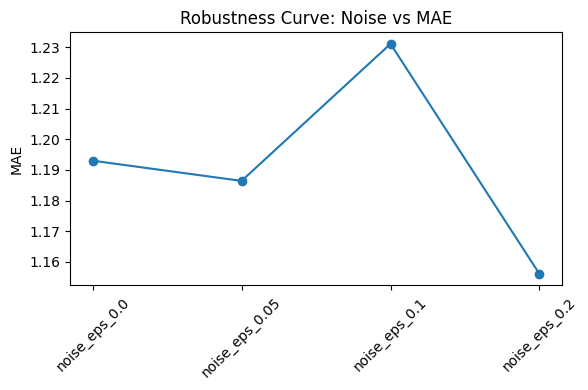

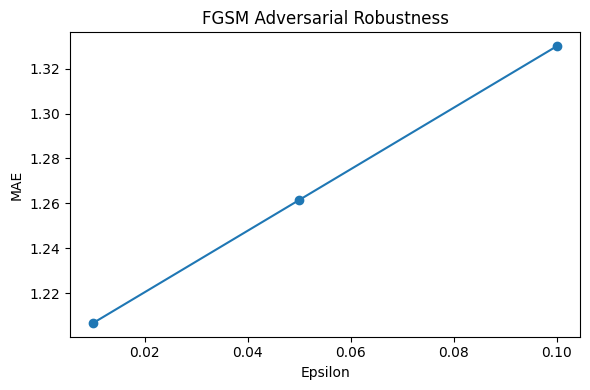

In [19]:
plt.figure(figsize=(6,4))
plt.plot(noise_df["scenario"], noise_df["MAE"], marker="o", label="Noise MAE")
plt.xticks(rotation=45)
plt.title("Robustness Curve: Noise vs MAE")
plt.ylabel("MAE")
plt.tight_layout()
plt.savefig("outputs/robustness_curve_noise_mae.png")
plt.show()

plt.figure(figsize=(6,4))
plt.plot(fgsm_df["epsilon"], fgsm_df["MAE"], marker="o")
plt.title("FGSM Adversarial Robustness")
plt.xlabel("Epsilon")
plt.ylabel("MAE")
plt.tight_layout()
plt.savefig("outputs/fgsm_robustness_curve.png")
plt.show()

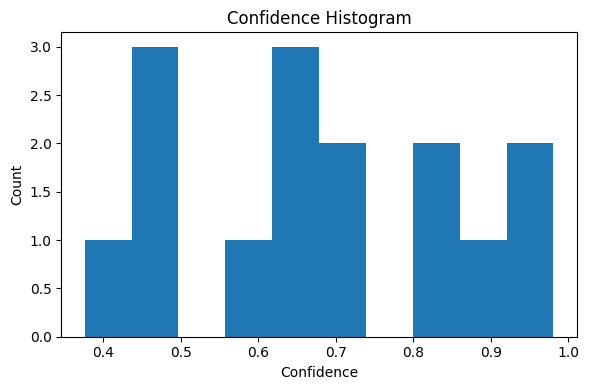

In [20]:
baseline_pred = test_df["roll2"].values.astype(np.float32)
confidence = 1.0 / (1.0 + np.abs(test_p - baseline_pred))

plt.figure(figsize=(6,4))
plt.hist(confidence, bins=10)
plt.title("Confidence Histogram")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("outputs/confidence_histogram.png")
plt.show()

/tmp/ipykernel_960/763834281.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calib = error_df.groupby("conf_bin")["abs_error"].mean().reset_index()


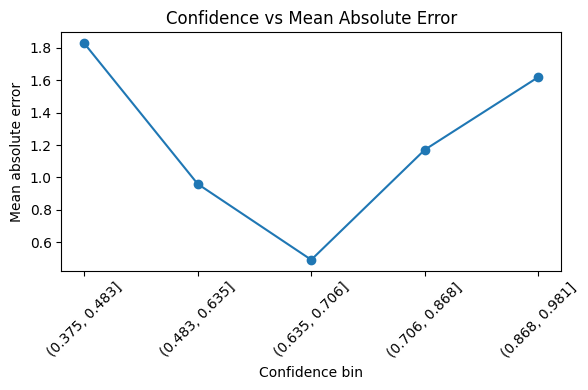

In [21]:
error_df = pd.DataFrame({
    "confidence": confidence,
    "abs_error": np.abs(test_y - test_p)
})

error_df["conf_bin"] = pd.qcut(error_df["confidence"], q=5, duplicates="drop")
calib = error_df.groupby("conf_bin")["abs_error"].mean().reset_index()

plt.figure(figsize=(6,4))
plt.plot(range(len(calib)), calib["abs_error"], marker="o")
plt.xticks(range(len(calib)), calib["conf_bin"].astype(str), rotation=45)
plt.title("Confidence vs Mean Absolute Error")
plt.xlabel("Confidence bin")
plt.ylabel("Mean absolute error")
plt.tight_layout()
plt.savefig("outputs/confidence_vs_error.png")
plt.show()

In [22]:
failure_examples = pd.DataFrame({
    "item_id": test_df["item_id"].values,
    "true": test_y,
    "pred": test_p,
    "baseline": baseline_pred,
    "confidence": confidence
})

failure_examples["abs_error"] = np.abs(failure_examples["true"] - failure_examples["pred"])
failure_examples = failure_examples.sort_values("abs_error", ascending=False).head(8).copy()

failure_examples["why_failed"] = [
    "high demand spike",
    "possible OOD input",
    "feature sensitivity",
    "missing pattern not seen",
    "rare item behavior",
    "baseline mismatch",
    "unit-related sensitivity",
    "low historical signal"
][:len(failure_examples)]

failure_examples["mitigation_idea"] = [
    "retrain with drifted data",
    "add confidence threshold",
    "use fallback baseline",
    "improve monitoring",
    "collect more history",
    "blend baseline + model",
    "add stronger validation",
    "regularize and retrain"
][:len(failure_examples)]

display(failure_examples)
failure_examples.to_csv("outputs/failure_examples_table.csv", index=False)

,item_id,true,pred,baseline,confidence,abs_error,why_failed,mitigation_idea
8,9,6.00,2.903393,3.00,0.911903,3.096607,high demand spike,retrain with drifted data
4,5,6.00,3.747477,2.50,0.444943,2.252523,possible OOD input,add confidence threshold
7,8,3.00,0.749287,1.00,0.799544,2.250713,feature sensitivity,use fallback baseline
1,2,5.00,6.843956,7.50,0.603849,1.843956,missing pattern not seen,improve monitoring
12,13,4.00,5.838634,7.50,0.375747,1.838634,rare item behavior,collect more history
5,6,4.00,2.530140,2.50,0.970742,1.469860,baseline mismatch,blend baseline + model
0,1,0.77,2.167304,1.08,0.479087,1.397304,unit-related sensitivity,add stronger validation
11,12,6.00,5.067837,4.00,0.483597,0.932163,low historical signal,regularize and retrain


In [23]:
train_df_drift = train_df.copy()
val_df_drift = val_df.copy()
test_df_drift = test_df.copy()

for col in ["last1", "last2", "roll2", "y"]:
    train_df_drift[col] = train_df_drift[col] * 1.2
    val_df_drift[col] = val_df_drift[col] * 1.2
    test_df_drift[col] = test_df_drift[col] * 1.2

# Mixed adaptation data
train_df_mixed = pd.concat([train_df, train_df_drift], ignore_index=True)
val_df_mixed = pd.concat([val_df, val_df_drift], ignore_index=True)

train_ds_mixed = ForecastDS(train_df_mixed)
val_ds_mixed = ForecastDS(val_df_mixed)
test_ds_drift = ForecastDS(test_df_drift)

train_loader_mixed = DataLoader(train_ds_mixed, batch_size=16, shuffle=True)
val_loader_mixed = DataLoader(val_ds_mixed, batch_size=64, shuffle=False)
test_loader_drift = DataLoader(test_ds_drift, batch_size=64, shuffle=False)

# Evaluate original model on drifted data
test_y_drift, test_p_orig_on_drift = predict(model_orig, test_loader_drift)
before_metrics = eval_metrics(test_y_drift, test_p_orig_on_drift)

# Retrain on mixed data
model_updated, history_updated, train_time_updated = train_model(
    train_loader_mixed, val_loader_mixed, in_dim=len(FEATURES), lr=0.01, weight_decay=1e-4, max_epochs=500, patience=80
)

test_y_drift2, test_p_updated = predict(model_updated, test_loader_drift)
after_metrics = eval_metrics(test_y_drift2, test_p_updated)

adaptation_df = pd.DataFrame([
    {"model": "original_on_drift", "MAE": before_metrics[0], "RMSE": before_metrics[1], "R2": before_metrics[2]},
    {"model": "updated_retrained_mixed", "MAE": after_metrics[0], "RMSE": after_metrics[1], "R2": after_metrics[2]}
])

display(adaptation_df)
adaptation_df.to_csv("outputs/adaptation_results.csv", index=False)

Early stop at epoch 334


,model,MAE,RMSE,R2
0,original_on_drift,1.505667,1.845808,0.501842
1,updated_retrained_mixed,1.519005,1.855553,0.496568


In [24]:
resolved_cases = pd.DataFrame({
    "item_id": test_df_drift["item_id"].values,
    "true": test_y_drift,
    "before_pred": test_p_orig_on_drift,
    "after_pred": test_p_updated
})

resolved_cases["before_error"] = np.abs(resolved_cases["true"] - resolved_cases["before_pred"])
resolved_cases["after_error"] = np.abs(resolved_cases["true"] - resolved_cases["after_pred"])
resolved_cases["improved"] = resolved_cases["after_error"] < resolved_cases["before_error"]

resolved_examples = resolved_cases[resolved_cases["improved"]].sort_values(
    "before_error", ascending=False
).head(2)

display(resolved_examples)
resolved_examples.to_csv("outputs/resolved_cases_after_adaptation.csv", index=False)

,item_id,true,before_pred,after_pred,before_error,after_error,improved
8,9,7.2,3.167098,3.379871,4.032902,3.820128,True
4,5,7.2,4.028631,4.215544,3.171369,2.984456,True


PSI last1: 1.4295241720589194
PSI roll2: 1.7577168406324448


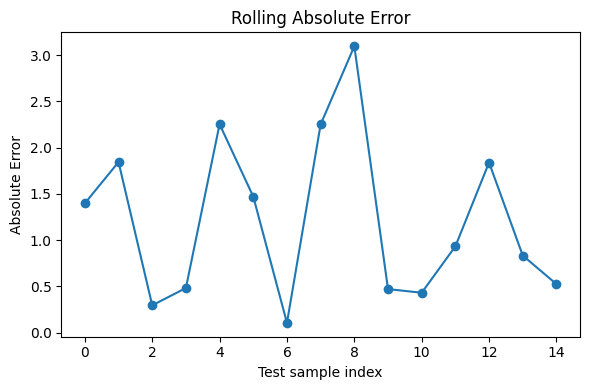

In [25]:
def compute_psi(expected, actual, bins=10):
    expected = np.array(expected)
    actual = np.array(actual)

    breakpoints = np.linspace(0, 100, bins + 1)
    breakpoints = np.percentile(expected, breakpoints)

    expected_counts = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    actual_counts = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    expected_counts = np.where(expected_counts == 0, 1e-6, expected_counts)
    actual_counts = np.where(actual_counts == 0, 1e-6, actual_counts)

    psi = np.sum((actual_counts - expected_counts) * np.log(actual_counts / expected_counts))
    return psi

psi_last1 = compute_psi(train_df["last1"], test_df["last1"])
psi_roll2 = compute_psi(train_df["roll2"], test_df["roll2"])

print("PSI last1:", psi_last1)
print("PSI roll2:", psi_roll2)

rolling_mae = np.abs(test_y - test_p)

plt.figure(figsize=(6,4))
plt.plot(range(len(rolling_mae)), rolling_mae, marker="o")
plt.title("Rolling Absolute Error")
plt.xlabel("Test sample index")
plt.ylabel("Absolute Error")
plt.tight_layout()
plt.savefig("outputs/rolling_mae_plot.png")
plt.show()

In [26]:
alerts = []

if psi_last1 > 0.2:
    alerts.append("ALERT: PSI for last1 exceeds threshold")

if psi_roll2 > 0.2:
    alerts.append("ALERT: PSI for roll2 exceeds threshold")

if np.mean(rolling_mae) > 1.5:
    alerts.append("ALERT: Rolling MAE exceeds threshold")

print("Monitoring alerts:")
if len(alerts) == 0:
    print("No alerts triggered")
else:
    for a in alerts:
        print("-", a)

Monitoring alerts:
- ALERT: PSI for last1 exceeds threshold
- ALERT: PSI for roll2 exceeds threshold


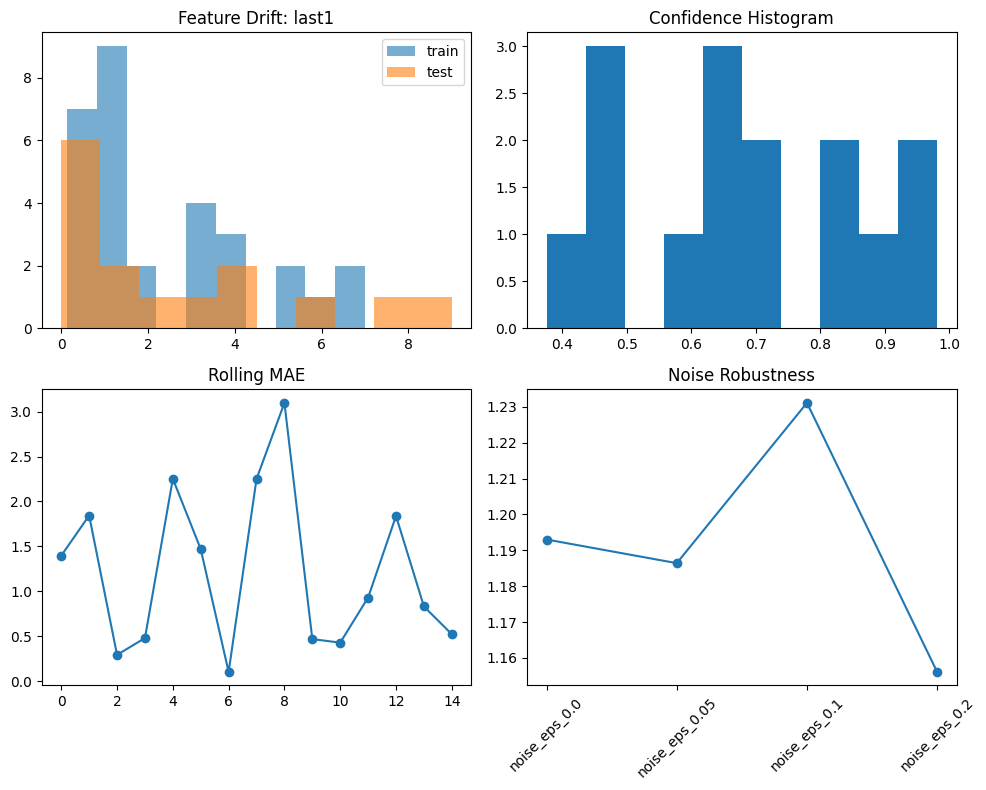

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0,0].hist(train_df["last1"], bins=10, alpha=0.6, label="train")
axes[0,0].hist(test_df["last1"], bins=10, alpha=0.6, label="test")
axes[0,0].set_title("Feature Drift: last1")
axes[0,0].legend()

axes[0,1].hist(confidence, bins=10)
axes[0,1].set_title("Confidence Histogram")

axes[1,0].plot(rolling_mae, marker="o")
axes[1,0].set_title("Rolling MAE")

axes[1,1].plot(noise_df["scenario"], noise_df["MAE"], marker="o")
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].set_title("Noise Robustness")

plt.tight_layout()
plt.savefig("outputs/monitoring_dashboard.png")
plt.show()

In [28]:
def latency_benchmark_array(model, X_array, n_runs=200):
    model.eval()
    times_ms = []

    with torch.no_grad():
        for _ in range(n_runs):
            idx = np.random.randint(0, len(X_array))
            xb = torch.tensor(X_array[idx:idx+1], dtype=torch.float32).to(device)

            t0 = time.perf_counter()
            _ = model(xb)
            t1 = time.perf_counter()

            times_ms.append((t1 - t0) * 1000.0)

    times_ms = sorted(times_ms)
    p50 = times_ms[int(0.5 * len(times_ms))]
    p90 = times_ms[int(0.9 * len(times_ms))]
    throughput = 1000.0 / float(np.mean(times_ms))
    return p50, p90, throughput

clean_p50, clean_p90, clean_thr = latency_benchmark_array(model_orig, X_test)
noisy_X = add_noise_to_array(X_test, 0.1)
noisy_p50, noisy_p90, noisy_thr = latency_benchmark_array(model_orig, noisy_X)

X_test_drift = test_df_drift[FEATURES].values.astype(np.float32)
updated_p50, updated_p90, updated_thr = latency_benchmark_array(model_updated, X_test_drift)

latency_df = pd.DataFrame([
    {"scenario": "clean", "p50_ms": clean_p50, "p90_ms": clean_p90, "throughput": clean_thr},
    {"scenario": "noise_eps_0.1", "p50_ms": noisy_p50, "p90_ms": noisy_p90, "throughput": noisy_thr},
    {"scenario": "updated_model_drift_data", "p50_ms": updated_p50, "p90_ms": updated_p90, "throughput": updated_thr}
])

display(latency_df)
latency_df.to_csv("outputs/latency_comparison.csv", index=False)

,scenario,p50_ms,p90_ms,throughput
0,clean,0.015573,0.032129,41790.505857
1,noise_eps_0.1,0.014109,0.015165,67547.691241
2,updated_model_drift_data,0.014362,0.015874,65035.003465


In [29]:
torch.save(model_orig.state_dict(), "outputs/restock_model_original_m3.pt")
torch.save(model_updated.state_dict(), "outputs/restock_model_updated_m3.pt")

size_orig_kb = os.path.getsize("outputs/restock_model_original_m3.pt") / 1024.0
size_updated_kb = os.path.getsize("outputs/restock_model_updated_m3.pt") / 1024.0

param_orig = sum(p.numel() for p in model_orig.parameters())
param_updated = sum(p.numel() for p in model_updated.parameters())

efficiency_df = pd.DataFrame([
    {"model": "original", "params": param_orig, "size_kb": size_orig_kb, "train_time_s": train_time_orig},
    {"model": "updated", "params": param_updated, "size_kb": size_updated_kb, "train_time_s": train_time_updated}
])

display(efficiency_df)
efficiency_df.to_csv("outputs/efficiency_comparison.csv", index=False)

,model,params,size_kb,train_time_s
0,original,7,2.114258,1.663424
1,updated,7,2.106445,1.890272


In [30]:
summary_df = pd.DataFrame([
    {"section": "clean_test", "MAE": eval_metrics(test_y, test_p)[0], "RMSE": eval_metrics(test_y, test_p)[1], "R2": eval_metrics(test_y, test_p)[2]},
    {"section": "ood_test", "MAE": ood_metrics[0], "RMSE": ood_metrics[1], "R2": ood_metrics[2]}
])

display(summary_df)
summary_df.to_csv("outputs/milestone3_summary_metrics.csv", index=False)

,section,MAE,RMSE,R2
0,clean_test,1.214601,1.487610,0.534055
1,ood_test,1.182775,1.597316,0.462797
